In [1]:
import pandas as pd
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

!unzip -q -o ml-latest-small.zip

--2026-06-02 08:05:40--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  2.66MB/s    in 0.4s    

2026-06-02 08:05:41 (2.66 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



Ratings shape: (100836, 4)
Movies shape: (9742, 3)
(100836, 6)
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64
   rating  label
0     4.0  Liked
1     4.0  Liked
2     4.0  Liked
3     5.0  Liked
4     5.0  Liked
label
Liked        48580
Neutral      33183
Not Liked    19073
Name: count, dtype: int64


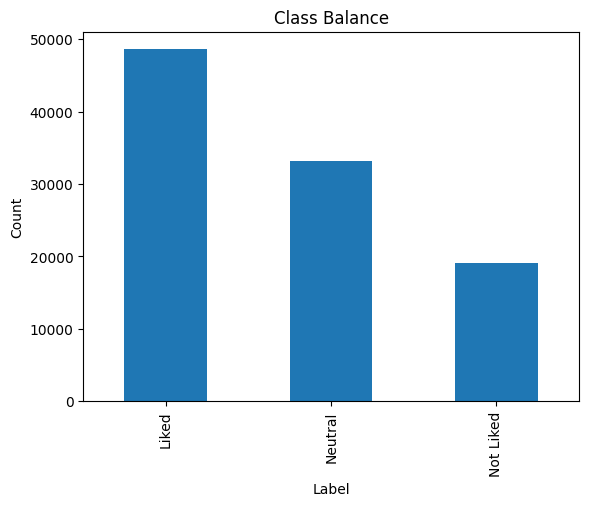

In [3]:
ratings = pd.read_csv("data/ratings.csv")
movies = pd.read_csv("data/movies.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

ratings.head()

movies.head()

df = ratings.merge(movies, on="movieId", how="left")

df.head()

print(df.shape)

print(df.isnull().sum())

df = df.dropna()

print(df.isnull().sum())

def rating_label(rating):
    if rating < 3:
        return "Not Liked"
    elif rating < 4:
        return "Neutral"
    else:
        return "Liked"

df["label"] = df["rating"].apply(rating_label)

print(df[["rating", "label"]].head())

print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.title("Class Balance")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

# Since the classes are not perfectly balanced,
# F1-score will be used as the main evaluation metric.

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder = LabelEncoder()

df["label_encoded"] = label_encoder.fit_transform(
    df["label"]
)

df["year"] = pd.to_datetime(
    df["timestamp"],
    unit='s'
).dt.year

df["movie_avg_rating"] = df.groupby(
    "movieId"
)["rating"].transform("mean")

genres_encoder = LabelEncoder()

df["genres_encoded"] = genres_encoder.fit_transform(
    df["genres"]
)

X = df[[
    "userId",
    "movieId",
    "year",
    "movie_avg_rating",
    "genres_encoded"
]]

y = df["label_encoded"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Features shape: (100836, 5)
Target shape: (100836,)
Train size: (80668, 5)
Test size: (20168, 5)



Training Logistic Regression...


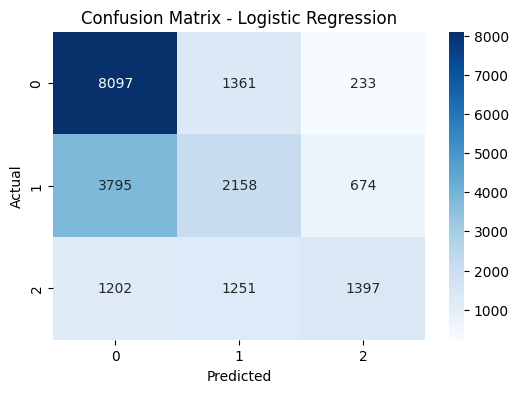


Training Random Forest...


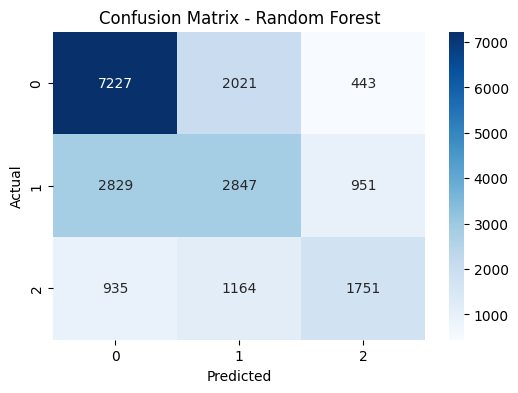


Training KNN...


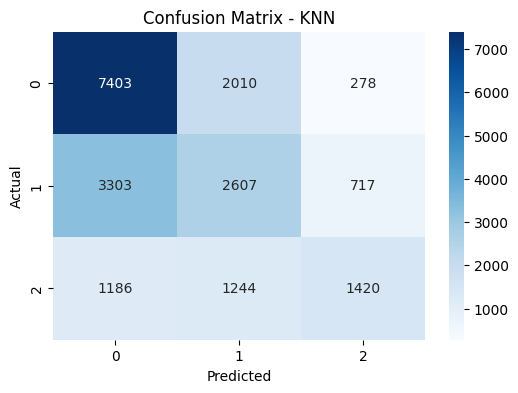


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.577747   0.561543  0.577747  0.552621
1        Random Forest  0.586325   0.577328  0.586325  0.579186
2                  KNN  0.566739   0.557533  0.566739  0.553363

Best Model: Random Forest


In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

results_df = pd.DataFrame(results)

print("\nModel Comparison:")
print(results_df)

best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model:", best_model_name)

# The best model is selected based on the highest
# F1-score because the dataset classes are imbalanced.

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2017/2017 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5707 - loss: 0.8943 - val_accuracy: 0.5740 - val_loss: 0.8891
Epoch 2/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5793 - loss: 0.8816 - val_accuracy: 0.5764 - val_loss: 0.8849
Epoch 3/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5809 - loss: 0.8794 - val_accuracy: 0.5785 - val_loss: 0.8848
Epoch 4/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5824 - loss: 0.8782 - val_accuracy: 0.5783 - val_loss: 0.8832
Epoch 5/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5819 - loss: 0.8774 - val_accuracy: 0.5803 - val_loss: 0.8825
Epoch 6/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5834 - loss: 0.8758 - val_accuracy: 0.5847 - val_loss: 0.8804
Epoch 7/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5851 - loss: 0.8755 - val_accuracy: 0.5845 - val_loss: 0.8829
Epoch 8/10
2017/2017 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5860 - loss: 0.8745 - val_accurac

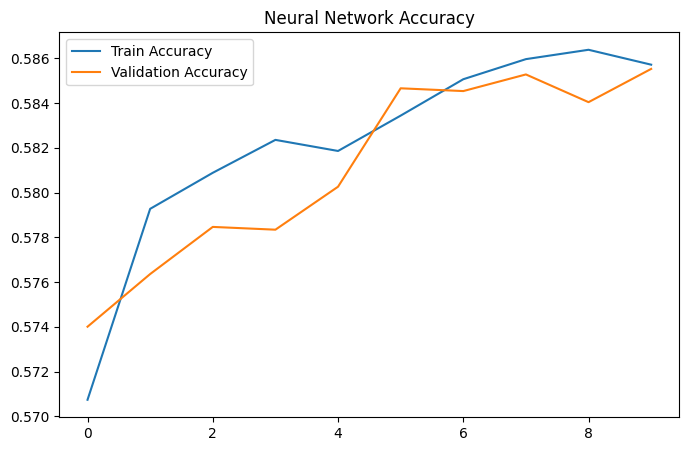

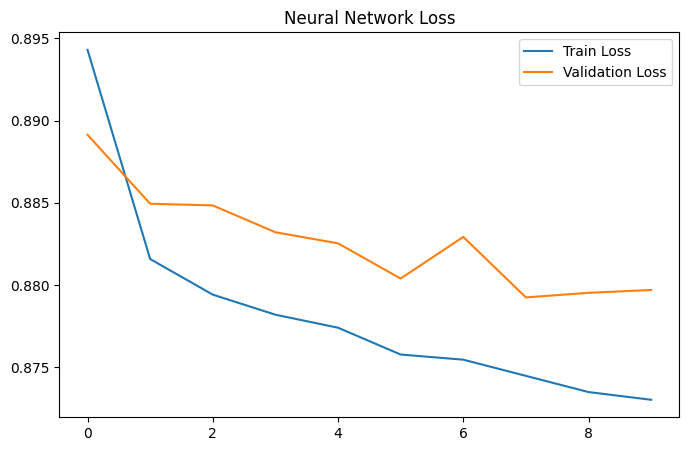

In [6]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

nn_model = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = nn_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Neural Network Accuracy")

plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Neural Network Loss")

plt.legend()

plt.show()

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


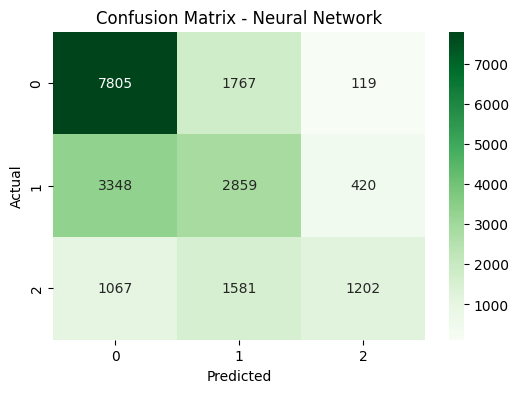


Final Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.577747   0.561543  0.577747  0.552621
1        Random Forest  0.586325   0.577328  0.586325  0.579186
2                  KNN  0.566739   0.557533  0.566739  0.553363
3       Neural Network  0.588358   0.590055  0.588358  0.570811

The Neural Network achieved competitive performance compared to the traditional machine learning models.
It was able to learn more complex patterns from the dataset using dense layers and nonlinear activation functions.
However, Random Forest may still perform similarly or better because the MovieLens dataset is relatively small and structured.



In [7]:
y_pred_nn_probs = nn_model.predict(X_test)

y_pred_nn = np.argmax(
    y_pred_nn_probs,
    axis=1
)

nn_acc = accuracy_score(y_test, y_pred_nn)

nn_precision = precision_score(
    y_test,
    y_pred_nn,
    average="weighted"
)

nn_recall = recall_score(
    y_test,
    y_pred_nn,
    average="weighted"
)

nn_f1 = f1_score(
    y_test,
    y_pred_nn,
    average="weighted"
)

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    cmap="Greens"
)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

nn_result = pd.DataFrame([{
    "Model": "Neural Network",
    "Accuracy": nn_acc,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1 Score": nn_f1
}])

results_df = pd.concat(
    [results_df, nn_result],
    ignore_index=True
)

print("\nFinal Comparison:")
print(results_df)

print("""
The Neural Network achieved competitive performance compared to the traditional machine learning models.
It was able to learn more complex patterns from the dataset using dense layers and nonlinear activation functions.
However, Random Forest may still perform similarly or better because the MovieLens dataset is relatively small and structured.
""")